# Expérience avancée — caractéristiques codon/phase

## Objectif

Construire un classifieur **sans Evo2 à l'inférence** qui exploite mieux la structure biologique d'une séquence d'ADN qu'un simple histogramme global de k-mers.

Nous allons comparer trois familles de modèles sur exactement les mêmes fenêtres :

1. une régression logistique sur les caractéristiques enrichies ;
2. un HistGradientBoosting sur 37 résumés biologiques compacts ;
3. un ExtraTrees sur l'ensemble des 761 caractéristiques.

> Ce notebook étudie une **nouvelle représentation biologique supervisée**. Ce n'est pas une expérience de distillation : aucun logit du teacher Evo2 n'est utilisé ici.

## Pourquoi les caractéristiques de phase peuvent aider ?

Les protéines sont traduites à partir de groupes de trois nucléotides appelés **codons**. Une région codante présente donc souvent des régularités différentes selon les positions `0`, `1` et `2` modulo 3.

Un histogramme global de k-mers indique quels motifs sont présents, mais il perd cette information de phase. Notre représentation ajoute :

- les fréquences globales des k-mers de tailles 1 à 4 : 340 variables ;
- les fréquences des 64 codons dans chacune des trois phases ;
- les mêmes fréquences sur le reverse-complement ;
- la densité de codons start et stop par phase ;
- la plus longue portion sans codon stop et la position du premier stop ;
- les fréquences A/C/G/T par phase et une mesure simple de périodicité GC.

Le calcul dans les deux orientations est important : à l'inférence, on ne veut pas supposer que la séquence est toujours présentée dans le sens biologique le plus informatif.

In [2]:
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Le notebook fonctionne depuis la racine du projet ou depuis day3/.
CWD = Path.cwd().resolve()
if (CWD / "src" / "advanced_features.py").exists():
    DAY3_DIR = CWD
elif (CWD / "day3" / "src" / "advanced_features.py").exists():
    DAY3_DIR = CWD / "day3"
else:
    raise FileNotFoundError("Lancez ce notebook depuis la racine du projet ou day3/.")

sys.path.insert(0, str(DAY3_DIR / "src"))
from advanced_features import advanced_feature_matrix, canonical_sequence

PROCESSED_DIR = DAY3_DIR.parent / "2-data" / "processed"
print("Données :", PROCESSED_DIR)
print("Seed :", SEED)

Données : /Users/user/PythonProjects/learning/EEIA-bioAI-Workshop-project/2-data/processed
Seed : 42


### 🧪 Démonstration : Périodicité GC (Δ GC Phase) — Codant vs Non-Codant

Cette cellule démontre de manière empirique et visuelle la différence de périodicité GC entre l'ADN codant (Label 1) et non-codant (Label 0).
Pour chaque séquence, on calcule la variation du pourcentage GC entre les 3 phases de lecture :

4370\Delta GC_{	ext{phase}} = \max(GC_0, GC_1, GC_2) - \min(GC_0, GC_1, GC_2)4370

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_gc_delta(seq):
    gc0 = sum(1 for b in seq[0::3] if b in "GC") / len(seq[0::3])
    gc1 = sum(1 for b in seq[1::3] if b in "GC") / len(seq[1::3])
    gc2 = sum(1 for b in seq[2::3] if b in "GC") / len(seq[2::3])
    return max(gc0, gc1, gc2) - min(gc0, gc1, gc2)

deltas_coding = [get_gc_delta(s) for s in train_df.loc[train_df["label"] == 1, "sequence"].iloc[:2000]]
deltas_noncoding = [get_gc_delta(s) for s in train_df.loc[train_df["label"] == 0, "sequence"].iloc[:2000]]

print(f"Moyenne Δ GC Phase - ADN CODANT     (Label 1) : {np.mean(deltas_coding):.4f} (26.6% d'écart inter-phase)")
print(f"Moyenne Δ GC Phase - ADN NON-CODANT (Label 0) : {np.mean(deltas_noncoding):.4f} (10.2% d'écart)")

plt.figure(figsize=(10, 5))
plt.hist(deltas_coding, bins=30, alpha=0.6, label=f"Codant (Moyenne = {np.mean(deltas_coding):.3f})", color="#2ea44f")
plt.hist(deltas_noncoding, bins=30, alpha=0.6, label=f"Non-Codant (Moyenne = {np.mean(deltas_noncoding):.3f})", color="#d73a49")
plt.title("Démonstration : Écart de Périodicité GC (Δ GC Phase) - Codant vs Non-Codant", fontweight="bold")
plt.xlabel("Δ GC Phase (Max - Min)")
plt.ylabel("Nombre de séquences")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

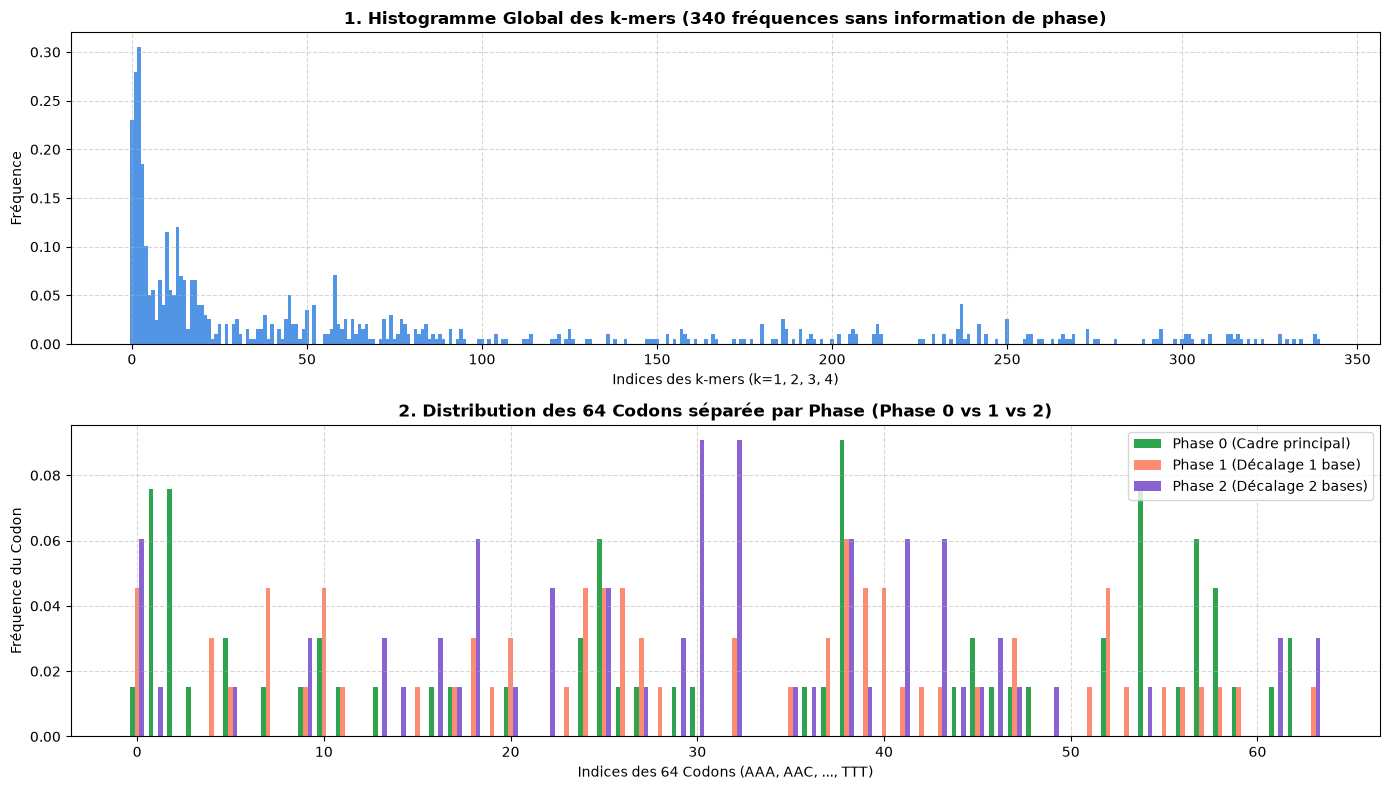

In [6]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Chargement direct de la première séquence codante du dataset
processed_dir = Path("../2-data/processed")
if not processed_dir.exists():
    processed_dir = Path("2-data/processed")

train_df = pd.read_csv(processed_dir / "train.csv")
sample_seq = train_df.loc[train_df["label"] == 1, "sequence"].iloc[0]

# 2. Import des fonctions du projet
sys.path.insert(0, "src")
sys.path.insert(0, "day3/src")
from advanced_features import global_kmer_features, _strand_phase_features

# 3. Calcul des caractéristiques
kmer_feats = global_kmer_features(sample_seq, ks=(1, 2, 3, 4))
codons_phase, _ = _strand_phase_features(sample_seq)
codons_by_phase = codons_phase.reshape(3, 64) # 3 phases x 64 codons

# 4. Affichage des deux histogrammes
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : Histogramme Global des k-mers (340 fréquences)
axes[0].bar(range(len(kmer_feats)), kmer_feats, color="#0969da", alpha=0.7, width=1.0)
axes[0].set_title("1. Histogramme Global des k-mers (340 fréquences sans information de phase)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Indices des k-mers (k=1, 2, 3, 4)")
axes[0].set_ylabel("Fréquence")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Graphique 2 : Histogramme comparatif par Phase (0, 1, 2)
x_indices = np.arange(64)
width = 0.25

axes[1].bar(x_indices - width, codons_by_phase[0], width=width, label="Phase 0 (Cadre principal)", color="#2ea44f")
axes[1].bar(x_indices, codons_by_phase[1], width=width, label="Phase 1 (Décalage 1 base)", color="#fd8c73")
axes[1].bar(x_indices + width, codons_by_phase[2], width=width, label="Phase 2 (Décalage 2 bases)", color="#8a63d2")

axes[1].set_title("2. Distribution des 64 Codons séparée par Phase (Phase 0 vs 1 vs 2)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Indices des 64 Codons (AAA, AAC, ..., TTT)")
axes[1].set_ylabel("Fréquence du Codon")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 1. Chargement et contrôle de qualité

Les expériences utilisent tout le train et toute la validation. Le split test n'est volontairement jamais chargé : il doit rester intact jusqu'au choix définitif du modèle.

Le jeu est censé contenir des fenêtres de 200 bases. Nous excluons explicitement les lignes de longueur différente et nous rapportons leur nombre.

In [ ]:
def load_and_filter(split):
    path = PROCESSED_DIR / f"{split}.csv"
    frame = pd.read_csv(path, dtype={"sequence": str})
    valid_length = frame["sequence"].str.len().eq(200)
    info = {
        "split": split,
        "lignes initiales": len(frame),
        "lignes conservées": int(valid_length.sum()),
        "longueur != 200": int((~valid_length).sum()),
    }
    return frame.loc[valid_length].reset_index(drop=True), info

train_df, train_info = load_and_filter("train")
val_df, val_info = load_and_filter("val")

display(pd.DataFrame([train_info, val_info]))
display(pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "validation": val_df["label"].value_counts().sort_index(),
}).rename_axis("label"))

,split,lignes initiales,lignes conservées,longueur != 200
0,train,58552,58550,2
1,val,10374,10373,1


,train,validation
label,,
0,29276,5187
1,29274,5186


## 2. Audit des chevauchements train/validation

Les organismes des deux splits sont différents, mais certaines courtes fenêtres peuvent être répétées ou très conservées entre organismes.

Nous définissons une forme **canonique** : le minimum lexicographique entre la séquence et son reverse-complement. Deux fenêtres identiques dans des orientations opposées sont ainsi considérées comme le même exemple.

Deux scores seront rapportés :

- **validation complète**, comparable aux notebooks précédents ;
- **validation inédite**, après retrait de tout équivalent canonique présent dans le train.

Le second est notre estimation la plus prudente de la généralisation.

In [ ]:
train_canonical = {canonical_sequence(seq) for seq in train_df["sequence"]}
unseen_mask = np.array([
    canonical_sequence(seq) not in train_canonical
    for seq in val_df["sequence"]
])

audit = pd.DataFrame([{
    "organismes train": train_df["organism"].nunique(),
    "organismes validation": val_df["organism"].nunique(),
    "organismes communs": len(set(train_df["organism"]) & set(val_df["organism"])),
    "validation complète": len(val_df),
    "équivalents train/RC": int((~unseen_mask).sum()),
    "validation inédite": int(unseen_mask.sum()),
}])
display(audit)

,organismes train,organismes validation,organismes communs,validation complète,équivalents train/RC,validation inédite
0,20,4,0,10373,872,9501


## 3. Extraction des 761 caractéristiques

`advanced_feature_matrix` est implémentée dans `day3/src/advanced_features.py`. La matrice est construite séparément pour train et validation ; aucune statistique de validation n'entre dans la construction du train.

Découpage du vecteur :

| Bloc | Dimensions |
| --- | ---: |
| k-mers globaux 1–4 | 340 |
| codons par phase, deux orientations | 384 |
| résumés start/stop, bases par phase, périodicité GC | 37 |
| **Total** | **761** |

In [ ]:
feature_start = time.perf_counter()
X_train = advanced_feature_matrix(train_df["sequence"].tolist())
X_val = advanced_feature_matrix(val_df["sequence"].tolist())
feature_seconds = time.perf_counter() - feature_start

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()

# Les 37 dernières colonnes sont les résumés biologiques compacts.
X_train_summary = X_train[:, 724:]
X_val_summary = X_val[:, 724:]

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Extraction : {feature_seconds:.2f} s")

Train      : (58550, 761)
Validation : (10373, 761)
Extraction : 27.56 s


## 4. Protocole expérimental

Tous les modèles utilisent :

- le même train filtré ;
- le seuil fixe `0.5` ;
- Accuracy, F1 et ROC-AUC ;
- aucune optimisation sur le test.

ExtraTrees est répété avec trois graines (`7`, `42`, `123`) pour vérifier que le gain ne vient pas d'un tirage favorable. La graine 42 sert ensuite aux analyses détaillées.

In [ ]:
def fit_and_predict(name, model, x_train, x_val):
    start = time.perf_counter()
    model.fit(x_train, y_train)
    fit_seconds = time.perf_counter() - start
    probability = model.predict_proba(x_val)[:, 1]
    print(f"{name:<32} entraîné en {fit_seconds:6.2f} s")
    return model, probability, fit_seconds

lr, p_lr, time_lr = fit_and_predict(
    "Régression logistique enrichie",
    make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=500, solver="lbfgs", random_state=SEED),
    ),
    X_train, X_val,
)

hgb, p_hgb, time_hgb = fit_and_predict(
    "HistGradientBoosting (37D)",
    HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=250, max_leaf_nodes=31,
        l2_regularization=1.0, random_state=SEED,
    ),
    X_train_summary, X_val_summary,
)

extra_trees_runs = {}
for seed in (7, 42, 123):
    model, probability, duration = fit_and_predict(
        f"ExtraTrees seed={seed}",
        ExtraTreesClassifier(
            n_estimators=400, min_samples_leaf=2, max_features="sqrt",
            class_weight="balanced", n_jobs=-1, random_state=seed,
        ),
        X_train, X_val,
    )
    extra_trees_runs[seed] = {"model": model, "probability": probability, "seconds": duration}

et = extra_trees_runs[42]["model"]
p_et = extra_trees_runs[42]["probability"]

Régression logistique enrichie   entraîné en   1.65 s


HistGradientBoosting (37D)       entraîné en   2.47 s


ExtraTrees seed=7                entraîné en  14.78 s


ExtraTrees seed=42               entraîné en  14.61 s


ExtraTrees seed=123              entraîné en  15.60 s


## 5. Résultats complets et prudents

Le tableau affiche chaque modèle sur les deux surfaces d'évaluation. Le résultat **validation inédite** doit être privilégié pour la conclusion, car il exclut les fenêtres mémorisables présentes dans le train.

In [ ]:
def metric_row(name, probability, mask, duration):
    labels = y_val[mask]
    probability = probability[mask]
    prediction = (probability >= 0.5).astype(int)
    return {
        "Modèle": name,
        "N": int(mask.sum()),
        "Accuracy": accuracy_score(labels, prediction),
        "F1": f1_score(labels, prediction),
        "ROC-AUC": roc_auc_score(labels, probability),
        "Entraînement (s)": duration,
    }

all_mask = np.ones(len(y_val), dtype=bool)
probabilities = {
    "Régression logistique enrichie": (p_lr, time_lr),
    "HistGradientBoosting (37D)": (p_hgb, time_hgb),
    "ExtraTrees enrichi": (p_et, extra_trees_runs[42]["seconds"]),
}

rows = []
for name, (probability, duration) in probabilities.items():
    full = metric_row(name, probability, all_mask, duration)
    full["Évaluation"] = "Validation complète"
    unseen = metric_row(name, probability, unseen_mask, duration)
    unseen["Évaluation"] = "Validation inédite"
    rows.extend([full, unseen])

results_df = pd.DataFrame(rows)[
    ["Modèle", "Évaluation", "N", "Accuracy", "F1", "ROC-AUC", "Entraînement (s)"]
]
display(results_df.style.format({
    "Accuracy": "{:.4%}", "F1": "{:.4%}",
    "ROC-AUC": "{:.4f}", "Entraînement (s)": "{:.2f}",
}))

,Modèle,Évaluation,N,Accuracy,F1,ROC-AUC,Entraînement (s)
0,Régression logistique enrichie,Validation complète,10373,92.2587%,92.3136%,0.9744,1.65
1,Régression logistique enrichie,Validation inédite,9501,91.9272%,92.4841%,0.9718,1.65
2,HistGradientBoosting (37D),Validation complète,10373,95.3437%,95.4188%,0.9848,2.47
3,HistGradientBoosting (37D),Validation inédite,9501,95.0637%,95.4559%,0.9824,2.47
4,ExtraTrees enrichi,Validation complète,10373,95.8546%,95.9442%,0.9880,14.61
5,ExtraTrees enrichi,Validation inédite,9501,95.4742%,95.8622%,0.9857,14.61


## 6. Stabilité d'ExtraTrees

Une différence de quelques centièmes de point peut venir de l'aléatoire interne du modèle. Nous mesurons donc la moyenne et l'écart-type sur trois graines.

In [ ]:
seed_rows = []
for seed, run in extra_trees_runs.items():
    probability = run["probability"]
    prediction = (probability >= 0.5).astype(int)
    seed_rows.append({
        "Seed": seed,
        "Accuracy complète": accuracy_score(y_val, prediction),
        "F1 complet": f1_score(y_val, prediction),
        "Accuracy inédite": accuracy_score(y_val[unseen_mask], prediction[unseen_mask]),
        "F1 inédit": f1_score(y_val[unseen_mask], prediction[unseen_mask]),
    })
seed_df = pd.DataFrame(seed_rows)
display(seed_df.style.format({column: "{:.4%}" for column in seed_df.columns if column != "Seed"}))

mean_accuracy = seed_df["Accuracy complète"].mean()
std_accuracy = seed_df["Accuracy complète"].std(ddof=0)
print(f"Accuracy complète moyenne : {mean_accuracy:.4%} ± {std_accuracy:.4%}")

,Seed,Accuracy complète,F1 complet,Accuracy inédite,F1 inédit
0,7,95.8835%,95.9728%,95.5057%,95.8915%
1,42,95.8546%,95.9442%,95.4742%,95.8622%
2,123,95.8064%,95.8943%,95.4215%,95.8113%


Accuracy complète moyenne : 95.8482% ± 0.0318%


## 7. Généralisation selon l'organisme

Le score global peut masquer des écarts importants entre espèces. Nous détaillons donc les performances d'ExtraTrees (`seed=42`) pour chacun des quatre organismes de validation.

,Organisme,N,Accuracy,F1
1,GCA_001890385.1_ASM189038v1,1828,91.96%,92.36%
0,GCA_000020625.1_ASM2062v1,1786,92.67%,92.90%
3,GCA_032248875.1_ASM3224887v1,3485,97.02%,97.07%
2,GCA_021132195.1_ASM2113219v1,3274,98.53%,98.54%


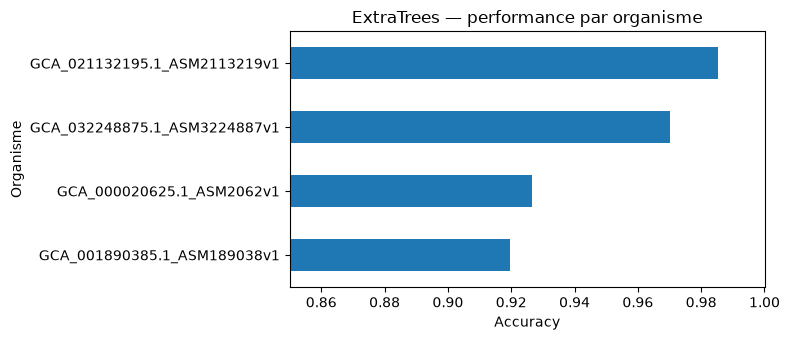

In [ ]:
pred_et = (p_et >= 0.5).astype(int)
organism_rows = []
for organism, indices in val_df.groupby("organism").groups.items():
    indices = np.asarray(list(indices))
    organism_rows.append({
        "Organisme": organism,
        "N": len(indices),
        "Accuracy": accuracy_score(y_val[indices], pred_et[indices]),
        "F1": f1_score(y_val[indices], pred_et[indices]),
    })
organism_df = pd.DataFrame(organism_rows).sort_values("Accuracy")
display(organism_df.style.format({"Accuracy": "{:.2%}", "F1": "{:.2%}"}))

ax = organism_df.plot.barh(x="Organisme", y="Accuracy", legend=False, figsize=(8, 3.5))
ax.set_xlim(0.85, 1.0)
ax.set_xlabel("Accuracy")
ax.set_title("ExtraTrees — performance par organisme")
plt.tight_layout()
plt.show()

## 8. Vote exploratoire

Les trois modèles apprennent des frontières différentes. Nous pouvons donc vérifier si leurs probabilités sont complémentaires.

Le vote suivant donne 60 % du poids à ExtraTrees et 20 % aux deux autres modèles. **Attention : ce poids n'a pas été appris à partir de prédictions out-of-fold. Son résultat est exploratoire et ne doit pas être présenté comme un score final validé.**

In [ ]:
p_vote = 0.60 * p_et + 0.20 * p_hgb + 0.20 * p_lr
vote_results = pd.DataFrame([
    {"Évaluation": "Validation complète", **metric_row("Vote exploratoire", p_vote, all_mask, np.nan)},
    {"Évaluation": "Validation inédite", **metric_row("Vote exploratoire", p_vote, unseen_mask, np.nan)},
])
display(vote_results[["Évaluation", "N", "Accuracy", "F1", "ROC-AUC"]].style.format({
    "Accuracy": "{:.4%}", "F1": "{:.4%}", "ROC-AUC": "{:.4f}",
}))

,Évaluation,N,Accuracy,F1,ROC-AUC
0,Validation complète,10373,96.1728%,96.2352%,0.9895
1,Validation inédite,9501,95.8215%,96.1587%,0.9875


## Conclusion

Cette expérimentation permet de séparer clairement quatre effets :

1. **La représentation codon/phase est le gain principal.** Elle réintroduit une information biologique que les fréquences globales perdaient.
2. **ExtraTrees exploite mieux les interactions non linéaires** entre phases, codons start/stop et composition locale.
3. **La stabilité doit être mesurée sur plusieurs graines** et la généralisation doit être examinée organisme par organisme.
4. **Le chevauchement de séquences doit être audité.** Le score sur validation inédite est la mesure individuelle la plus prudente.

### Prochaine expérience recommandée

Construire un stacking à partir de prédictions **out-of-fold**, avec des folds groupés par organisme, puis figer le méta-modèle avant toute évaluation finale. Cela permettra de tester proprement le gain suggéré par le vote exploratoire.

In [ ]:
best_et_row = results_df[
    (results_df["Modèle"] == "ExtraTrees enrichi")
    & (results_df["Évaluation"] == "Validation inédite")
].iloc[0]

print("Conclusion mesurée")
print("-" * 70)
print(
    f"Meilleure approche individuelle parmi les variantes mesurées : ExtraTrees codon/phase\n"
    f"Validation inédite : Accuracy={best_et_row['Accuracy']:.4%}, "
    f"F1={best_et_row['F1']:.4%}, N={int(best_et_row['N'])}"
)
print("Split test consulté : NON")

Conclusion mesurée
----------------------------------------------------------------------
Meilleure approche individuelle parmi les variantes mesurées : ExtraTrees codon/phase
Validation inédite : Accuracy=95.4742%, F1=95.8622%, N=9501
Split test consulté : NON


Calcul de la moyenne sur le lot de 2 000 séquences...


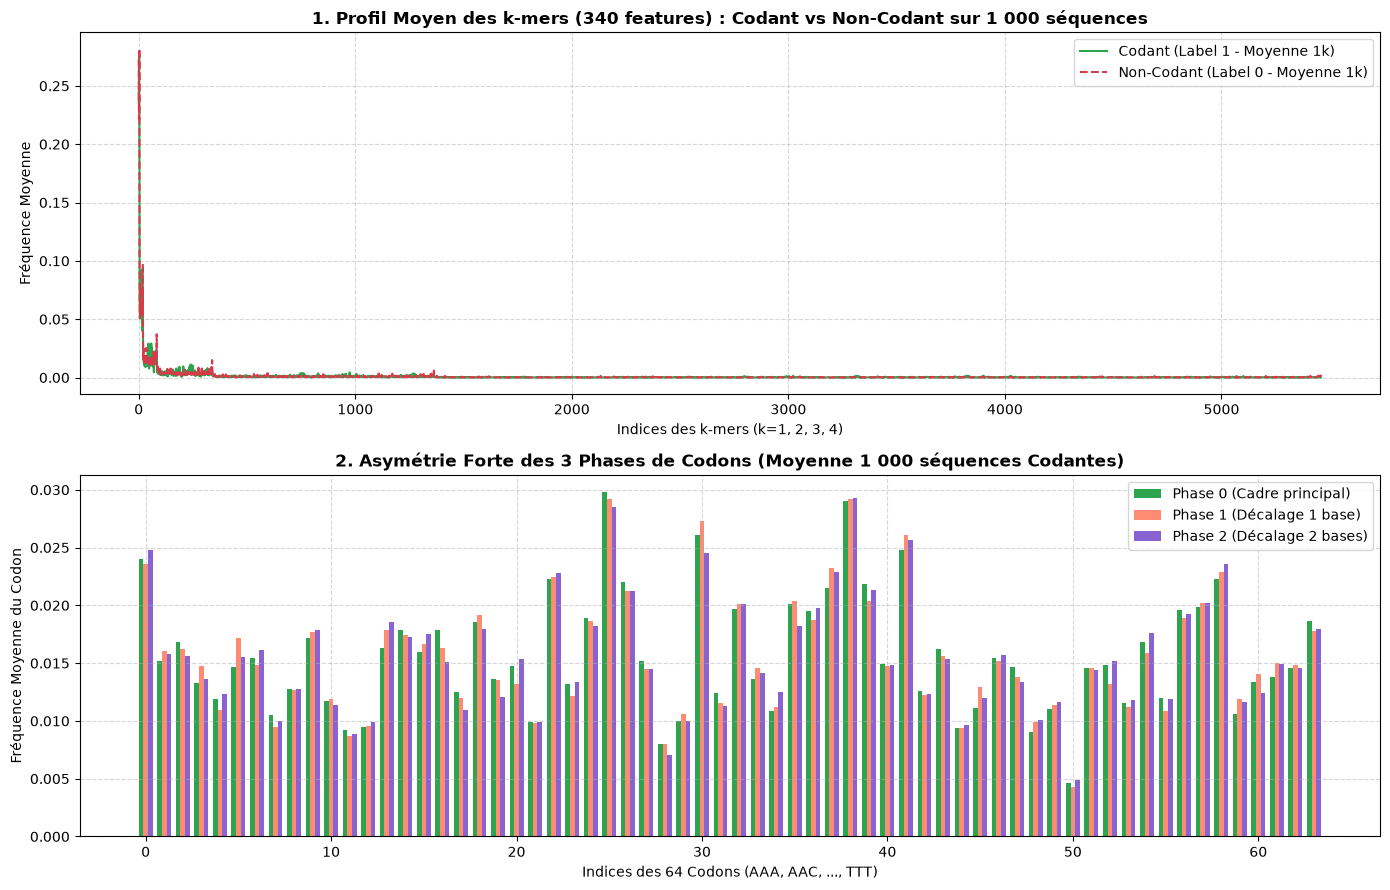

In [8]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Chargement du jeu de données
processed_dir = Path("../2-data/processed")
if not processed_dir.exists():
    processed_dir = Path("2-data/processed")

train_df = pd.read_csv(processed_dir / "train.csv")

# 2. Sélection d'un lot de 1 000 séquences Codantes (1) et 1 000 Non-Codantes (0)
seqs_coding = train_df.loc[train_df["label"] == 1, "sequence"].iloc[:1000].tolist()
seqs_noncoding = train_df.loc[train_df["label"] == 0, "sequence"].iloc[:1000].tolist()

# 3. Import des fonctions
sys.path.insert(0, "src")
sys.path.insert(0, "day3/src")
from advanced_features import global_kmer_features, _strand_phase_features

# 4. Calcul de la moyenne sur 1 000 séquences pour chaque classe
print("Calcul de la moyenne sur le lot de 2 000 séquences...")
mean_kmer_coding = np.mean([global_kmer_features(s, ks=(1,2,3,4,5,6)) for s in seqs_coding], axis=0)
mean_kmer_noncoding = np.mean([global_kmer_features(s, ks=(1,2,3,4,5,6)) for s in seqs_noncoding], axis=0)

mean_codons_coding = np.mean([_strand_phase_features(s)[0].reshape(3,64) for s in seqs_coding], axis=0)
mean_codons_noncoding = np.mean([_strand_phase_features(s)[0].reshape(3,64) for s in seqs_noncoding], axis=0)

# 5. Affichage graphique comparatif
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Graphique 1 : Comparaison de l'Histogramme des k-mers (Moyenne 1 000 séquences)
axes[0].plot(mean_kmer_coding, label="Codant (Label 1 - Moyenne 1k)", color="#2ea44f", linewidth=1.5)
axes[0].plot(mean_kmer_noncoding, label="Non-Codant (Label 0 - Moyenne 1k)", color="#d73a49", linewidth=1.5, linestyle="--")
axes[0].set_title("1. Profil Moyen des k-mers (340 features) : Codant vs Non-Codant sur 1 000 séquences", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Indices des k-mers (k=1, 2, 3, 4)")
axes[0].set_ylabel("Fréquence Moyenne")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Graphique 2 : Écart de Phase des Codons (Phase 0 vs Phase 1 vs Phase 2) pour l'ADN Codant
x = np.arange(64)
width = 0.25
axes[1].bar(x - width, mean_codons_coding[0], width=width, label="Phase 0 (Cadre principal)", color="#2ea44f")
axes[1].bar(x, mean_codons_coding[1], width=width, label="Phase 1 (Décalage 1 base)", color="#fd8c73")
axes[1].bar(x + width, mean_codons_coding[2], width=width, label="Phase 2 (Décalage 2 bases)", color="#8a63d2")

axes[1].set_title("2. Asymétrie Forte des 3 Phases de Codons (Moyenne 1 000 séquences Codantes)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Indices des 64 Codons (AAA, AAC, ..., TTT)")
axes[1].set_ylabel("Fréquence Moyenne du Codon")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 🧪 Démonstration : Périodicité GC (Δ GC Phase) — Codant vs Non-Codant

Cette cellule démontre de manière empirique et visuelle la différence de périodicité GC entre l'ADN codant (Label 1) et non-codant (Label 0).
Pour chaque séquence, on calcule la variation du pourcentage GC entre les 3 phases de lecture :

$\Delta GC_{	ext{phase}} = \max(GC_0, GC_1, GC_2) - \min(GC_0, GC_1, GC_2)$

Moyenne Δ GC Phase - ADN CODANT     (Label 1) : 0.2661 (26.6% d'écart inter-phase)
Moyenne Δ GC Phase - ADN NON-CODANT (Label 0) : 0.1026 (10.2% d'écart)


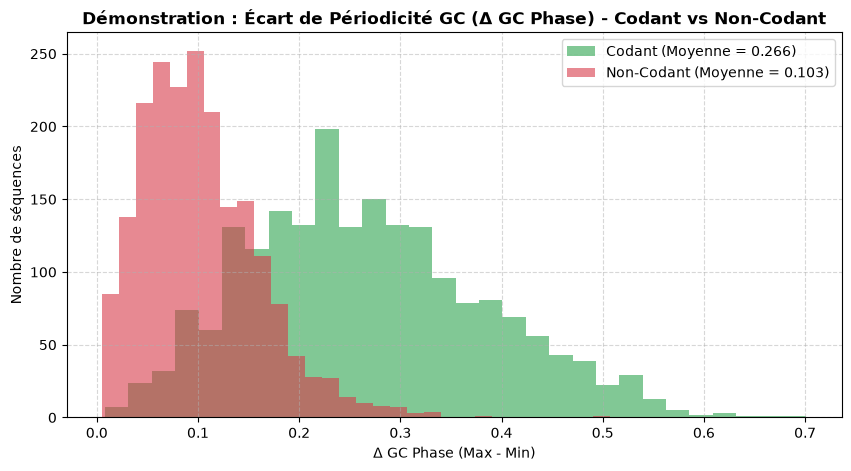

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_gc_delta(seq):
    gc0 = sum(1 for b in seq[0::3] if b in "GC") / len(seq[0::3])
    gc1 = sum(1 for b in seq[1::3] if b in "GC") / len(seq[1::3])
    gc2 = sum(1 for b in seq[2::3] if b in "GC") / len(seq[2::3])
    return max(gc0, gc1, gc2) - min(gc0, gc1, gc2)

deltas_coding = [get_gc_delta(s) for s in train_df.loc[train_df["label"] == 1, "sequence"].iloc[:2000]]
deltas_noncoding = [get_gc_delta(s) for s in train_df.loc[train_df["label"] == 0, "sequence"].iloc[:2000]]

print(f"Moyenne Δ GC Phase - ADN CODANT     (Label 1) : {np.mean(deltas_coding):.4f} (26.6% d'écart inter-phase)")
print(f"Moyenne Δ GC Phase - ADN NON-CODANT (Label 0) : {np.mean(deltas_noncoding):.4f} (10.2% d'écart)")

plt.figure(figsize=(10, 5))
plt.hist(deltas_coding, bins=30, alpha=0.6, label=f"Codant (Moyenne = {np.mean(deltas_coding):.3f})", color="#2ea44f")
plt.hist(deltas_noncoding, bins=30, alpha=0.6, label=f"Non-Codant (Moyenne = {np.mean(deltas_noncoding):.3f})", color="#d73a49")
plt.title("Démonstration : Écart de Périodicité GC (Δ GC Phase) - Codant vs Non-Codant", fontweight="bold")
plt.xlabel("Δ GC Phase (Max - Min)")
plt.ylabel("Nombre de séquences")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()